In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids

# Activity 1. Data Loading and Processing
## 1. Load the Dataset


In [2]:
url = "https://gist.githubusercontent.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/8bd6144a87988213693754baaa13fb204933282d/Mall_Customers.csv"
data = pd.read_csv(url, encoding="iso8859-1")

## 2. Explore the dataset
a) Check the data shape  
b) Display the first 3 rows  
c) Summarize columns and data types  


In [3]:
# 2(a) 数据维度
print("Shape of data:", data.shape)

# 2(b) 前 3 行
print("\nFirst 3 rows:")
display(data.head(3))

# 2(c) 列名与数据类型
print("\nData info:")
print(data.info())


Shape of data: (200, 5)

First 3 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6



Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


## 3. Data processing
- a) Encode categorical variables such as Gender into numeric form (e.g. 0 for Male, 1 for Female)
- b) Select only numerical features relevant to clustering
- c) Apply feature scaling (e.g. StandardScaler) to ensure all variables contribute equally to the distance metric
- d) Remove irrelevant columns such as CustomerID that should not affect clustering

In [4]:
# 3(a) encode Gender
data_processed = data.copy()
data_processed["Gender_encoded"] = data_processed["Gender"].map({"Male": 0, "Female": 1})

# 3(b) select numerical features
feature_cols = ["Gender_encoded", "Age", "Annual Income (k$)", "Spending Score (1-100)"]
X = data_processed[feature_cols]

# 3(c) feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3(d) CustomerID is excluded from features
print("Selected feature columns:", feature_cols)
print("Scaled feature matrix shape:", X_scaled.shape)

Selected feature columns: ['Gender_encoded', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Scaled feature matrix shape: (200, 4)


# Activity 2. Distance Metrics and Similarity

1. Select two customers and display their information:
- CustomerID = 1
- CustomerID = 200  


In [5]:
# 1.
cust1 = data_processed[data_processed["CustomerID"] == 1]
cust200 = data_processed[data_processed["CustomerID"] == 200]

print("CustomerID = 1:")
display(cust1)

print("CustomerID = 200:")
display(cust200)

# Extract the corresponding feature vectors (already scaled)
# First find their row indices in the original data, then take the same positions in X_scaled
idx1 = cust1.index[0]
idx200 = cust200.index[0]

x1 = X_scaled[idx1].reshape(1, -1)
x200 = X_scaled[idx200].reshape(1, -1)

CustomerID = 1:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender_encoded
0,1,Male,19,15,39,0


CustomerID = 200:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender_encoded
199,200,Male,30,137,83,0


2. Compute manually or using Python the following distances:
- a) Euclidean distance
- b) Manhattan distance
- c) Chebyshev distance
- d) Cosine similarity


In [6]:
# a) Euclidean
euclidean_dist = pairwise_distances(x1, x200, metric="euclidean")[0, 0]

# b) Manhattan
manhattan_dist = pairwise_distances(x1, x200, metric="manhattan")[0, 0]

# c) Chebyshev
chebyshev_dist = pairwise_distances(x1, x200, metric="chebyshev")[0, 0]

# d) Cosine similarity
cos_sim = cosine_similarity(x1, x200)[0, 0]

print(f"Euclidean distance  : {euclidean_dist:.4f}")
print(f"Manhattan distance  : {manhattan_dist:.4f}")
print(f"Chebyshev distance  : {chebyshev_dist:.4f}")
print(f"Cosine similarity   : {cos_sim:.4f}")


Euclidean distance  : 5.0225
Manhattan distance  : 7.1543
Chebyshev distance  : 4.6567
Cosine similarity   : -0.3933


3. Which distance metric best represents customer similarity in this dataset? Why?

> **Euclidean distance** best represents customer similarity in this dataset because all features were standardized, making Euclidean distance a balanced measure of overall differences across Age, Income, Gender, and Spending Score. 
> 
> It also matches the assumptions of clustering algorithms like K-Means and GMM, which operate in Euclidean space. 
> 
> Other metrics (Manhattan, Chebyshev, Cosine) are less suitable for low-dimensional continuous data or do not capture magnitude differences properly.

# Activity 3. K-Means and Elbow Method

## 1. Apply ordinary K-Means Clustering
- a) Apply K-Means(n_clusters=3, random_state=42)  
- b) Plot Annual Income vs Spending Score and color by cluster assignment

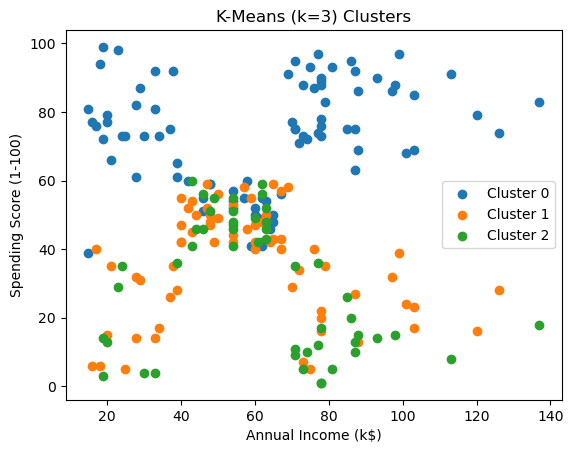

In [7]:
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_k3 = kmeans_3.fit_predict(X_scaled)

data_processed["Cluster_k3"] = labels_k3

plt.figure()
for lbl in np.unique(labels_k3):
    subset = data_processed[data_processed["Cluster_k3"] == lbl]
    plt.scatter(subset["Annual Income (k$)"],
                subset["Spending Score (1-100)"],
                label=f"Cluster {lbl}")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means (k=3) Clusters")
plt.legend()
plt.show()

## 2. Apply Elbow method
- a) Apply the Elbow Method using k = 1 – 10
- b) Plot WCSS vs k, identify the elbow point, and justify your chosen k
- c) Apply the ordinary K-Means method with n_clusters=k in b), random_state=42
- d) Color points by cluster label by Annual Income and Spending Score

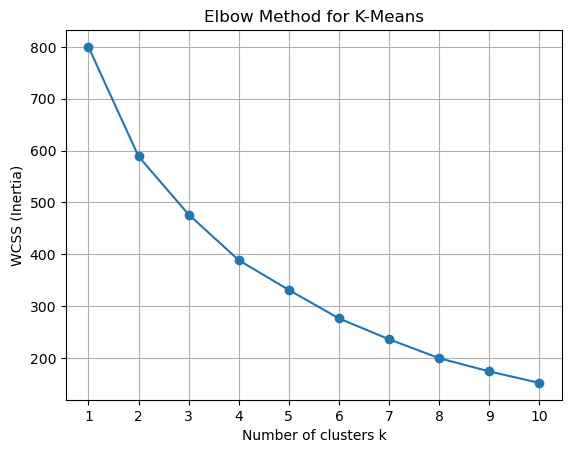

Chosen k (from elbow): 5


In [8]:
# 3.2 (a)
wcss = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# 3.2 (b)
plt.figure()
plt.plot(list(K_range), wcss, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for K-Means")
plt.xticks(list(K_range))
plt.grid(True)
plt.show()

best_k = 5
print("Chosen k (from elbow):", best_k)

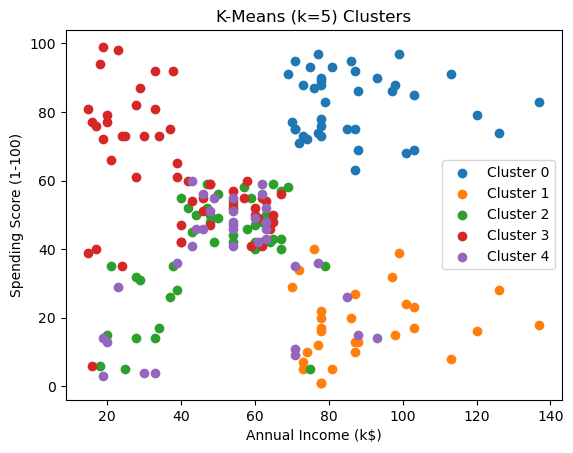

In [9]:
# 3.2(c) use best_k to cluster
kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_k_best = kmeans_best.fit_predict(X_scaled)
data_processed[f"Cluster_k{best_k}"] = labels_k_best

# 3.2(d) visualize best_k clusters
plt.figure()
for lbl in np.unique(labels_k_best):
    subset = data_processed[data_processed[f"Cluster_k{best_k}"] == lbl]
    plt.scatter(subset["Annual Income (k$)"],
                subset["Spending Score (1-100)"],
                label=f"Cluster {lbl}")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title(f"K-Means (k={best_k}) Clusters")
plt.legend()
plt.show()

## 2(e) Difference between the two clustering results

> When using k = 3, the K-Means model produces only three broad customer groups. These clusters mix together customers who have different spending behaviors or income levels because the model is forced to group them into only three categories.
> 
> With the optimal k = 5 (from the Elbow Method), the clustering becomes more detailed and meaningful. Customers with similar income and spending patterns are separated more clearly—for example, high-income high-spending customers, high-income low-spending customers, medium-income customers, or low-income groups are better distinguished. The clusters are more compact and visually more separated on the scatter plot.

## 3. Apply K-Means++ and K-Medoids

- a) Apply K-Means ++ and K‑Medoids
- b) Compare cluster centroids with K-Means using plots
- c) Discuss robustness to outliers

In [10]:
# 3.3(a) K-Means (random init) vs K-Means++
k = best_k

kmeans_random = KMeans(n_clusters=k, init="random", random_state=42, n_init=10)
labels_kmeans_random = kmeans_random.fit_predict(X_scaled)

kmeans_pp = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
labels_kmeans_pp = kmeans_pp.fit_predict(X_scaled)

print("K-Means (random init) centroids:")
print(pd.DataFrame(kmeans_random.cluster_centers_, columns=feature_cols))

print("\nK-Means++ centroids:")
print(pd.DataFrame(kmeans_pp.cluster_centers_, columns=feature_cols))

K-Means (random init) centroids:
   Gender_encoded       Age  Annual Income (k$)  Spending Score (1-100)
0        0.130946 -1.002939           -0.754773                0.385997
1       -0.043390 -0.441917            0.991583                1.239503
2       -0.708453  0.007775            1.157106               -1.324462
3       -1.128152  1.230799           -0.507399               -0.412803
4        0.886405  0.711546           -0.175549               -0.505594

K-Means++ centroids:
   Gender_encoded       Age  Annual Income (k$)  Spending Score (1-100)
0       -0.043390 -0.441917            0.991583                1.239503
1       -0.016672 -0.169889            1.105281               -1.250054
2        0.886405  0.786847           -0.432362               -0.393271
3        0.065660 -1.000614           -0.795366                0.427181
4       -1.128152  1.210294           -0.262388               -0.521318


In [11]:
# 3.3(a) K-Medoids
kmedoids = KMedoids(n_clusters=k, random_state=42, metric="euclidean")
labels_kmedoids = kmedoids.fit_predict(X_scaled)
medoid_centers_idx = kmedoids.medoid_indices_
print("K-Medoids medoid indices:", medoid_centers_idx)

K-Medoids medoid indices: [ 36 168  45 137  89]


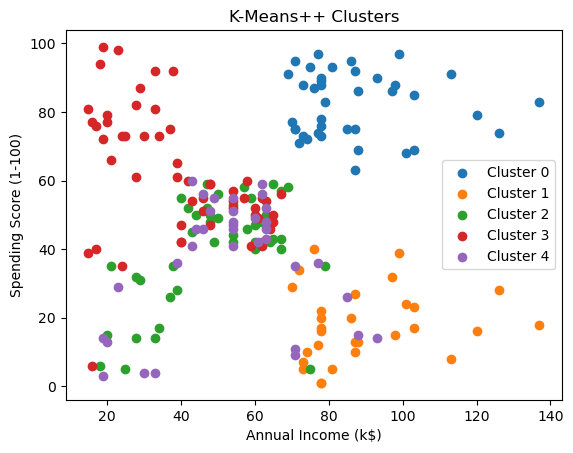

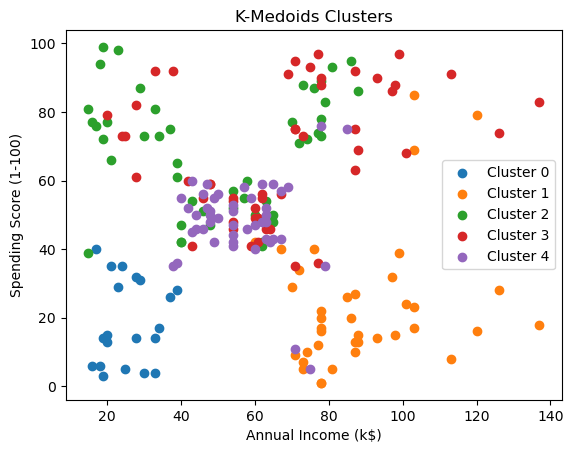

In [12]:
# 3.3(b) Use Annual Income vs Spending Score to compare K-Means++ and K-Medoids

# K-Means++ Visualization
plt.figure()
for lbl in np.unique(labels_kmeans_pp):
    subset = data_processed[labels_kmeans_pp == lbl]
    plt.scatter(subset["Annual Income (k$)"],
                subset["Spending Score (1-100)"],
                label=f"Cluster {lbl}")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means++ Clusters")
plt.legend()
plt.show()

# K-Medoids Visualization
plt.figure()
for lbl in np.unique(labels_kmedoids):
    subset = data_processed[labels_kmedoids == lbl]
    plt.scatter(subset["Annual Income (k$)"],
                subset["Spending Score (1-100)"],
                label=f"Cluster {lbl}")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Medoids Clusters")
plt.legend()
plt.show()

## 3(c) Discuss robustness to outliers

> **K-Means / K-Means++** use the **mean** as the cluster center, which makes them highly sensitive to outliers. A few extreme customers with unusually high or low income or spending scores can significantly pull the cluster center away from the majority of the data.
> 
> **K-Medoids**, on the other hand, selects an actual data point as the center (the medoid), which behaves more like a **median-based** representative. This makes it more robust to outliers, since extreme values do not affect the center as strongly.
> 
> Therefore, in datasets that contain noticeable outliers or noise, **K-Medoids is generally more stable and less affected by extreme points** compared to K-Means.

# Activity 4. Other Clustering Methods

## 1. Density-Based Clustering (DBSCAN)

- a) Apply the DBSCAN using eps=0.6, min_samples=5
- b) Identify core, border, and noise points visually
- c) Why DBSCAN cannot specify random_state?


In [13]:
# 4.1(a) DBSCAN
dbscan = DBSCAN(eps=0.6, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

data_processed["Cluster_DBSCAN"] = labels_dbscan

unique_labels = np.unique(labels_dbscan)
print("DBSCAN labels (including noise = -1):", unique_labels)

DBSCAN labels (including noise = -1): [-1  0  1  2  3  4  5  6  7  8]


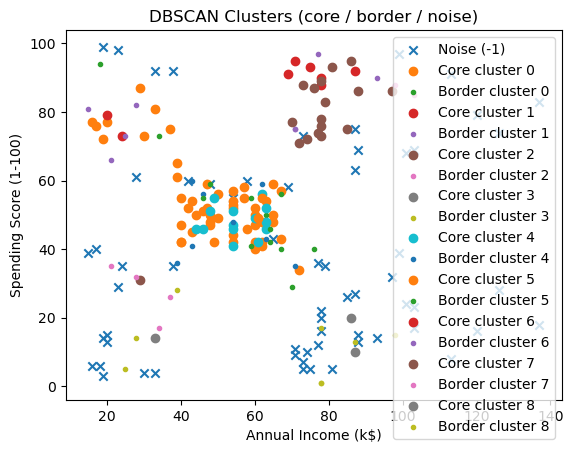

In [14]:
# 4.1(b) visualize DBSCAN clusters
core_samples_mask = np.zeros_like(labels_dbscan, dtype=bool)
if hasattr(dbscan, "core_sample_indices_"):
    core_samples_mask[dbscan.core_sample_indices_] = True

plt.figure()
for lbl in unique_labels:
    class_member_mask = (labels_dbscan == lbl)
    if lbl == -1:
        # noise points
        xy = data_processed[class_member_mask]
        plt.scatter(xy["Annual Income (k$)"], xy["Spending Score (1-100)"],
                    marker="x", label="Noise (-1)")
    else:
        # core points
        core_xy = data_processed[class_member_mask & core_samples_mask]
        plt.scatter(core_xy["Annual Income (k$)"], core_xy["Spending Score (1-100)"],
                    marker="o", label=f"Core cluster {lbl}")
        # border points
        border_xy = data_processed[class_member_mask & ~core_samples_mask]
        plt.scatter(border_xy["Annual Income (k$)"], border_xy["Spending Score (1-100)"],
                    marker=".", label=f"Border cluster {lbl}")

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Clusters (core / border / noise)")
plt.legend()
plt.show()

## 1(c) Why DBSCAN cannot specify `random_state`?

> DBSCAN does not rely on random initialization (unlike K-Means, which requires randomly selecting initial centers).
> 
> With the same hyperparameters `eps` and `min_samples`, the algorithm is **deterministic**, meaning it will always produce the same clustering result. Therefore, DBSCAN **does not need a `random_state` parameter** to control randomness.

## 2. Gaussian Mixture Model (GMM)

- a) Apply the GMM using `n_components`=5, `random_state`=42
- b) Plot the GMM clusters by Annual Income and Spending Score

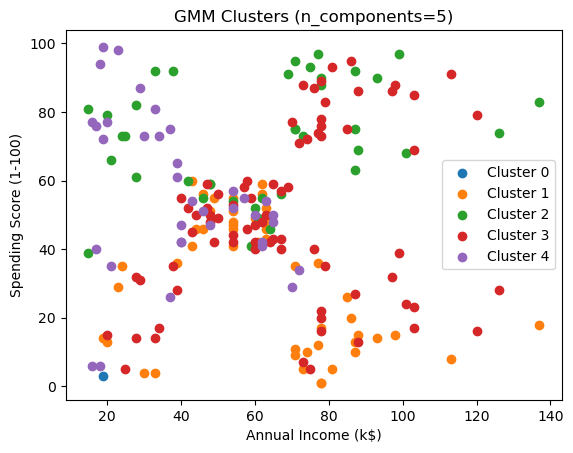

In [15]:
# 4.2(a) GMM
gmm = GaussianMixture(n_components=5, random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)
data_processed["Cluster_GMM"] = labels_gmm

# 4.2(b) Plot
plt.figure()
for lbl in np.unique(labels_gmm):
    subset = data_processed[data_processed["Cluster_GMM"] == lbl]
    plt.scatter(subset["Annual Income (k$)"],
                subset["Spending Score (1-100)"],
                label=f"Cluster {lbl}")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("GMM Clusters (n_components=5)")
plt.legend()
plt.show()

# Activity 5. Clustering Evaluation

1. Compute the Silhouette Coefficient for all the algorithms
- a) K-Means 
- b) K-Means++ 
- c) K-Medoids 
- d) DBSCAN  
- e) GMM  


In [16]:
# 5.1
sil_scores = {}

# a) K-Means (random init)
sil_scores["KMeans (random)"] = silhouette_score(
    X_scaled, labels_kmeans_random)

# b) K-Means++
sil_scores["KMeans++"] = silhouette_score(X_scaled, labels_kmeans_pp)

# c) K-Medoids
if len(np.unique(labels_kmedoids)) > 1:
    sil_scores["K-Medoids"] = silhouette_score(X_scaled, labels_kmedoids)
else:
    sil_scores["K-Medoids"] = np.nan

# d) DBSCAN (handling noise)
labels_dbscan_valid = labels_dbscan
# If there is more than one cluster (including noise)
if len(np.unique(labels_dbscan_valid)) > 1:
    try:
        sil_scores["DBSCAN"] = silhouette_score(X_scaled, labels_dbscan_valid)
    except Exception as e:
        sil_scores["DBSCAN"] = np.nan
else:
    sil_scores["DBSCAN"] = np.nan

# e) GMM
sil_scores["GMM"] = silhouette_score(X_scaled, labels_gmm)

print("Silhouette Coefficients:")
for model, score in sil_scores.items():
    print(f"{model:15s}: {score:.4f}" if not np.isnan(
        score) else f"{model:15s}: NaN")

Silhouette Coefficients:
KMeans (random): 0.3044
KMeans++       : 0.3041
K-Medoids      : 0.2431
DBSCAN         : 0.0938
GMM            : 0.2216


## 2. Which model produces the highest silhouette score?

> **K-Means (random)** has the highest silhouette score (0.3044), so it performs the best. 


## 3. Why does the clustering performance in the Mall Customers dataset appear to be not so good? How to improve?

> The clustering performance appears weak because the dataset contains **only a few basic features** (Gender, Age, Income, Spending Score), which do not fully capture customer behavior. 
> 
> The customer groups also **overlap heavily**, making it difficult for algorithms like K-Means to separate them clearly. 
> 
> In addition, real customer segments may **not form spherical clusters**, which conflicts with the assumptions of K-Means and reduces silhouette scores.
> 
> Improve:
> * Add more informative features (e.g., purchase frequency, product categories, online behavior).
> * Apply feature engineering such as RFM (Recency, Frequency, Monetary) metrics.
> * Try clustering methods better suited for complex shapes (e.g., DBSCAN, GMM, Spectral Clustering).
> * Tune parameters or choose a different value of *k*.
> * Remove or handle outliers to reduce noise.